# PyTorch Workflow

Let's explore an example PyTorch end-to-end workflow
Resouces:
* https://github.com/mrdbourke/pytorch-deep-learning/blob/main/01_pytorch_workflow.ipynb
* https://www.learnpytorch.io/01_pytorch_workflow/

In [1]:
what_we_are_covering = {1: "data (prepare and load)",
                        2: "build model",
                        3: "fitting the model to data (training)",
                        4: "making predictions and evaluating a model (inference)",
                        5: "saving and loading model",
                        6: "putting it all together"}

what_we_are_covering

{1: 'data (prepare and load)',
 2: 'build model',
 3: 'fitting the model to data (training)',
 4: 'making predictions and evaluating a model (inference)',
 5: 'saving and loading model',
 6: 'putting it all together'}

In [2]:
import torch
from torch import nn
import matplotlib.pyplot as plt

# check pytorch version
torch.__version__

'2.7.0+cu118'

## 1. Data (preparing and loading)

Data can be:
* Excel spreadsheet
* Images of any kind
* Videos
* Audio
* DNA
* Text

Machine learning is a game of two parts:
1. Get data into a numerical representation.
2. Build a model to learn patterns in that numerical representation.

To showcase this, let's create some **known** data using the linear regression formula: Y = a + bX

We'll use a linear regression formula to build a straight line with known **parameters**.

In [3]:
# Create known parameters
weight = 0.7
bias = 0.3

# Create
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
Y = weight * X + bias

X[:10], Y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [4]:
len(X), len(Y)

(50, 50)

### Splitting data into training and test sets

Generalization - The ability of a machine learning model to perform well on data it hasn't seen before.

In [5]:
# Create a train/test split
train_split = int(0.8 * len(X))
X_train, Y_train = X[:train_split], Y[:train_split]
X_test, Y_test = X[train_split:], Y[train_split:]

len(X_train), len(X_train), len(X_test), len(Y_test)

(40, 40, 10, 10)

How might we better visualize our data

This is where the data explorer's motto comes in!

In [23]:
def plot_predictions(train_data=X_train, 
                     train_labels=Y_train,
                     test_data=X_test,
                     test_labels=Y_test,
                     predictions=None):
    """ Plots training data, test data and compares predictions. """
    plt.Figure(figsize=(10,7))

    # Plot training data in blue
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

    # Plot test data in green
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

    # Are these predictions?
    if predictions is not None:
        # plot predictions if they exist
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")
    # show the legend
    plt.legend(prop={"size": 14})

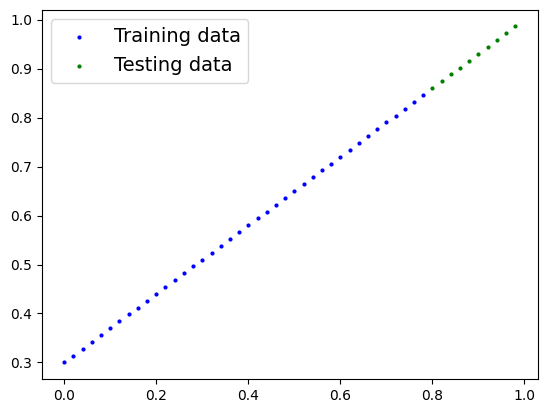

In [7]:
plot_predictions()

## Build model

Our first PyTorch Model

What our model does?
* Start with random values (weight & bias)
* Look at training data and adjust the random values to better represent (or get closer to) the ideal values (the weight and bias values we used to create the data)

How does it do so?

Through two main algorithms:
1. Gradient Descent
2. Backpropogation

In [15]:
from torch import nn

# Create a linear regression model class
class LinearRegressionModel(nn.Module):     # <- almost everything in PyTorch inherits from nn.Module
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,
                                                requires_grad=True,
                                                dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1,
                                                requires_grad=True,
                                                dtype=torch.float))
    
    # Forward method to define the computations in the model
    def forward(self, x:torch.Tensor) -> torch.Tensor:      # "x" is the input data
        return self.weights * x + self.bias     # linear regression formula

### PyTorch model building essentials:

* torch.nn - contains all the buildings of the computational graph (neural networks)
* torch.nn.Parameter - what parameters a model should try and learn, often a PyTorch layer from torch.nn will set these for us.
* torch.nn.Module - The base class for all neural network modules, if you subclass it, you should overwrite forward().
* torch.optim - this is where optimizers in PyTorch live, they will help with gradient descent
* def forward() - All nn.Module subclasses require us to overwrite the forward(), this method defines what happens in the forward computation.

In [16]:
# Create a manual seed
torch.manual_seed(42)

# create an instance of the model
model_0 = LinearRegressionModel()
# check out the parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [17]:
# List of parameters (name)
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [18]:
weight, bias

(0.7, 0.3)

### Making predictions using `torch.inference_mode()`

To check our model's predictive power, let's see how it predicts `Y_test` based on `X_test`.

When we pass data through our model, it's going to run through forward method.

In [ ]:
# make predictions with model
with torch.inference_mode():
    y_preds = model_0(X_test)       # can do the same with torch.no_grad() but torch.inference_mode() is preferred.

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [20]:
Y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

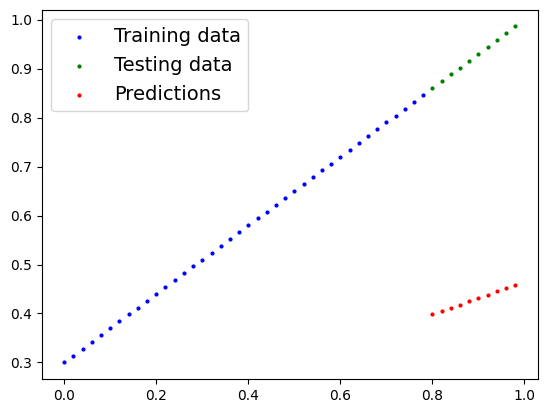

In [24]:
plot_predictions(predictions=y_preds)

## Train model

The whole idea of training is for a model is to move from some *unknown* parameters(these may be random) to some *known* parameters.

Or in other words from a poor representation of data to a better representation of data.

One way to measure how poor a model's predictions are to use loss functions.
https://docs.pytorch.org/docs/stable/nn.html#loss-functions

* Note: Loss functions may also be called cost function or criterion in different areas. We call it loss function.

* **Loss Function:** A function to measure how wrong your model's predictions are to real outputs, lower is better.

* **Optimizers:** Take into account the loss of a model and adjusts the model's parameters. (e.g. weights and bias). https://docs.pytorch.org/docs/stable/optim.html

Specifically for PyTorch, we need:
* Training loop
* Testing loop

In [25]:
# Setup a loss function
loss_fn = nn.L1Loss()

# Setup an optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(), 
                            lr=0.01)        # lr is most important hyperparameter

### Building a training loop (and a testing loop) in PyTorch

A couple of things we need in a training loop:
0. Loop through the data
1. Forward pass (this involves data moving through our model's `forward()` function) to make predictions on the data - also called forward propogation
2. Calculate the loss (compare forward pass predictions to ground truth labels)
3. Optimizer zero grad
4. Loss backward - to move backward through the network to calculate gradients of each parameters of our model with respect to the loss. (**backpropogation**)
5. Optimizer step - use the optimizer to adjust our model's parameters to try and improve the loss. (**gradient descent**)

In [ ]:
# epochs - an epoch is one loop through the data
epochs = 1

### Training

# 0. Loop through the data
for epoch in range(epochs):
    # set the model to training mode
    model_0.train()     # train mode in PyTorch sets all parameters that require gradients to require gradient.

    # 1. Forward pass
    y_pred = model_0(X_train)

    # 2. Calculate the loss
    loss = loss_fn(y_pred, Y_train)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Perform backpropogation on the loss wrt the parameters of the model
    loss.backward()

    # 5. Step the optimizer (perform gradient descent)
    optimizer.step()    # by default changes will be accumulated through the loop... so we have to zero them in step 3

    model_0.eval()      # turns off gradient tracking


### Testing
